В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [49]:
import pandas as pd
medical_df = pd.read_csv('data/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

1. Метод МНК
Intercept: -2091.4206
Slope: 267.2489
RMSE: 4662.5058

2. Full-Batch градієнтний спуск (numpy)

Learning rate: 0.0001
Intercept: -758.5424
Slope: 237.2384
RMSE: 4684.0364

Learning rate: 0.0005
Intercept: -1873.6337
Slope: 262.3453
RMSE: 4663.0819

Learning rate: 0.001
Intercept: 901095846734434507505140612343046905506205041289426621923995499486422351161626432976535996171330041334498966733644291314659149750655467062764425445376.0000
Slope: 40020979664091763403197662542412189708417721881957245741111224292031623541987692230682621043492602526777145228809264978310235886196563765955219406454784.0000
RMSE: inf

Найкращий learning rate: 0.0005, бо він дав найменший RMSE без розходження градієнтного спуску.


/opt/anaconda3/envs/machine-learning/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


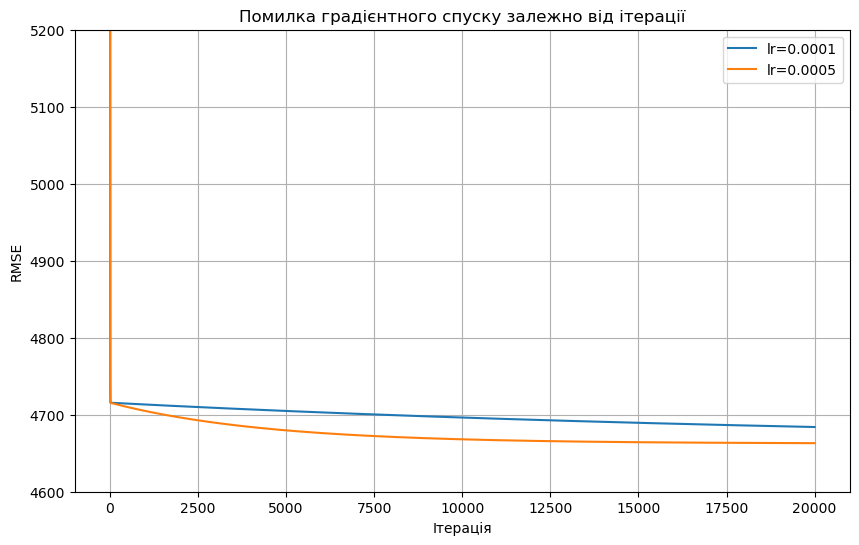


3. LinearRegression (scikit-learn)
Intercept: -2091.4206
Slope: 267.2489
RMSE: 4662.5058


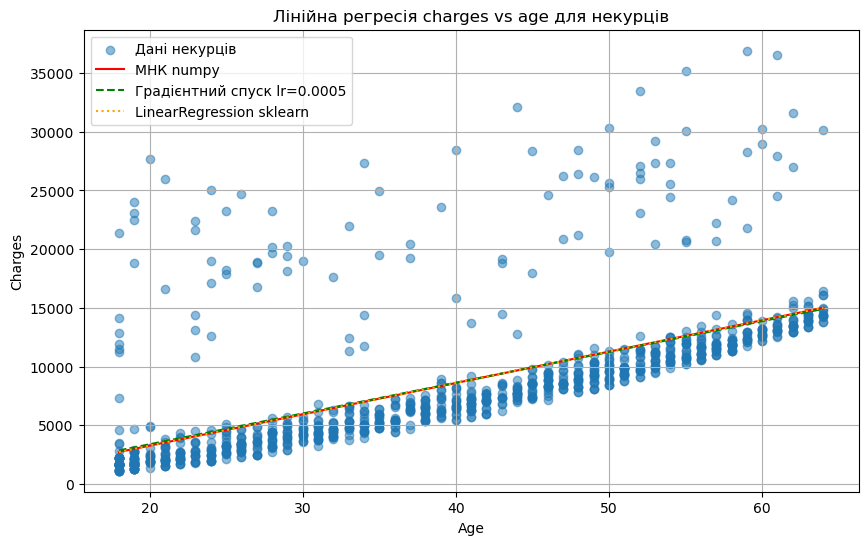

In [50]:
import numpy as np
import matplotlib.pyplot as plt

X = non_smoker_df['age'].to_numpy()
y = non_smoker_df['charges'].to_numpy()


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


# 1. Метод МНК з numpy
X_matrix = np.c_[np.ones(len(X)), X]

ols_coefficients, *_ = np.linalg.lstsq(X_matrix, y, rcond=None)
ols_intercept, ols_slope = ols_coefficients

ols_predictions = X_matrix @ ols_coefficients
ols_rmse = rmse(y, ols_predictions)

print("1. Метод МНК")
print(f"Intercept: {ols_intercept:.4f}")
print(f"Slope: {ols_slope:.4f}")
print(f"RMSE: {ols_rmse:.4f}")


# 2. Full-Batch градієнтний спуск з numpy
def gradient_descent(X_values, y_values, learning_rate, iterations=20000):
    X_gd = np.c_[np.ones(len(X_values)), X_values]
    theta = np.zeros(2)
    n = len(y_values)
    errors = []

    for i in range(iterations):
        predictions = X_gd @ theta
        error = predictions - y_values
        gradient = (2 / n) * (X_gd.T @ error)
        theta = theta - learning_rate * gradient
        errors.append(rmse(y_values, predictions))

        if not np.isfinite(errors[-1]):
            break

    return theta, errors


learning_rates = [0.0001, 0.0005, 0.001]
gd_results = {}

print("\n2. Full-Batch градієнтний спуск (numpy)")
for lr in learning_rates:
    theta, errors = gradient_descent(X, y, lr)
    predictions = X_matrix @ theta
    current_rmse = rmse(y, predictions)

    gd_results[lr] = {
        'theta': theta,
        'predictions': predictions,
        'rmse': current_rmse,
        'errors': errors
    }

    print(f"\nLearning rate: {lr}")
    print(f"Intercept: {theta[0]:.4f}")
    print(f"Slope: {theta[1]:.4f}")
    print(f"RMSE: {current_rmse:.4f}")

best_lr = min(gd_results, key=lambda lr: gd_results[lr]['rmse'])
best_gd_theta = gd_results[best_lr]['theta']
best_gd_predictions = gd_results[best_lr]['predictions']

print(f"\nНайкращий learning rate: {best_lr}, бо він дав найменший RMSE без розходження градієнтного спуску.")

# Щоб графік був зрозумілий, використовуємо тільки ті learning rates, за яких алгоритм зійшовся
learning_rates_for_plot = [0.0001, 0.0005]

plt.figure(figsize=(10, 6))

for lr in learning_rates_for_plot:
    plt.plot(gd_results[lr]['errors'], label=f"lr={lr}")

plt.ylim(4600, 5200)
plt.xlabel("Ітерація")
plt.ylabel("RMSE")
plt.title("Помилка градієнтного спуску залежно від ітерації")
plt.legend()
plt.grid(True)
plt.show()

# 3. LinearRegression з scikit-learn
from sklearn.linear_model import LinearRegression

sklearn_model = LinearRegression()
sklearn_model.fit(non_smoker_df[['age']], y)

sklearn_predictions = sklearn_model.predict(non_smoker_df[['age']])
sklearn_rmse = rmse(y, sklearn_predictions)

print("\n3. LinearRegression (scikit-learn)")
print(f"Intercept: {sklearn_model.intercept_:.4f}")
print(f"Slope: {sklearn_model.coef_[0]:.4f}")
print(f"RMSE: {sklearn_rmse:.4f}")

# Графік даних і трьох ліній регресії
age_line = np.linspace(X.min(), X.max(), 100)
age_line_matrix = np.c_[np.ones(len(age_line)), age_line]

ols_line = age_line_matrix @ ols_coefficients
gd_line = age_line_matrix @ best_gd_theta
sklearn_line = sklearn_model.predict(pd.DataFrame({'age': age_line}))

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label="Дані некурців")
plt.plot(age_line, ols_line, color="red", label="МНК numpy")
plt.plot(age_line, gd_line, color="green", linestyle="--", label=f"Градієнтний спуск lr={best_lr}")
plt.plot(age_line, sklearn_line, color="orange", linestyle=":", label="LinearRegression sklearn")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Лінійна регресія charges vs age для некурців")
plt.legend()
plt.grid(True)
plt.show()


**Висновки**

*Результати МНК numpy та LinearRegression sklearn практично однакові, оскільки sklearn для лінійної регресії знаходить ті самі оптимальні параметри.
Градієнтний спуск дає близький результат, якщо learning rate достатньо малий і модель встигає збігтися.
Знайдені параметри близькі до очікувань: для некурців charges зростають із віком, тому коефіцієнт при age додатний.*
1. Метод МНК
Intercept: -2091.4206
Slope: 267.2489
RMSE: 4662.5058

2. Full-Batch градієнтний спуск (numpy)

Learning rate: 0.0001
Intercept: -758.5424
Slope: 237.2384
RMSE: 4684.0364

Learning rate: 0.0005
Intercept: -1873.6337
Slope: 262.3453
RMSE: 4663.0819

Learning rate: 0.001
RMSE: inf
Алгоритм не зійшовся

3. LinearRegression (scikit-learn)
Intercept: -2091.4206
Slope: 267.2489
RMSE: 4662.5058

Найкращий learning rate: 0.0005, бо він дав найменший RMSE без розходження градієнтного спуску.


 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

Лінійна регресія для курців: charges vs age
RMSE: 10711.0033
R²: 0.1356
Intercept: 20294.1281
Slope: 305.2376


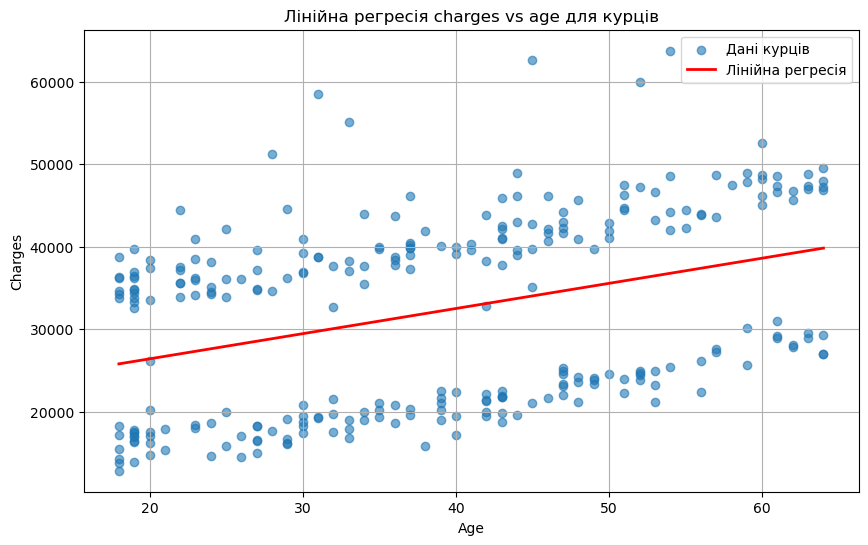

In [51]:
smoker_df = medical_df[medical_df.smoker == 'yes']

X_smoker = smoker_df[['age']]
y_smoker = smoker_df['charges']

smoker_model = LinearRegression()
smoker_model.fit(X_smoker, y_smoker)

smoker_predictions = smoker_model.predict(X_smoker)

smoker_rmse = rmse(y_smoker, smoker_predictions)
smoker_r2 = smoker_model.score(X_smoker, y_smoker)

print("Лінійна регресія для курців: charges vs age")
print(f"RMSE: {smoker_rmse:.4f}")
print(f"R²: {smoker_r2:.4f}")
print(f"Intercept: {smoker_model.intercept_:.4f}")
print(f"Slope: {smoker_model.coef_[0]:.4f}")

# Графік: age vs charges + лінія регресії
age_line_smoker = np.linspace(smoker_df['age'].min(), smoker_df['age'].max(), 100)
age_line_smoker_df = pd.DataFrame({'age': age_line_smoker})
charges_line_smoker = smoker_model.predict(age_line_smoker_df)

plt.figure(figsize=(10, 6))
plt.scatter(smoker_df['age'], y_smoker, alpha=0.6, label="Дані курців")
plt.plot(
    age_line_smoker,
    charges_line_smoker,
    color="red",
    linewidth=2,
    label="Лінійна регресія"
)

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Лінійна регресія charges vs age для курців")
plt.legend()
plt.grid(True)
plt.show()

**Висновки:**

Модель має R² = 0.1356, тобто вік пояснює лише невелику частину зміни медичних витрат курців.
RMSE = 10711.0033, що є досить великою помилкою прогнозу.
Коефіцієнт при age додатний, тобто з віком charges у середньому зростають, але точки на графіку сильно розкидані навколо лінії.
Тому модель charges vs age для курців не є достатньо хорошою для використання в компанії як основна модель.
Для реальних прогнозів слід використовувати модель з більшою кількістю ознак.